### Build A Basic Chatbot With Langgraph(GRAPH API)

In [27]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [5]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]
    
# graph_builder = StateGraph(State)

In [6]:
# graph_builder

In [8]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama3-8b-8192")

In [9]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000286A094BE00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000286A0A00D70>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [15]:
# Another way to initialize LLM model
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000286A2474B90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000286A2475810>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [16]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [17]:
# IMP STEPS
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

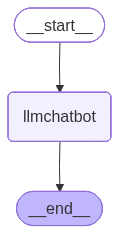

In [18]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [19]:
response=graph.invoke({"messages":"Hi"})

In [20]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='db42a1ff-e1d1-48d1-9c46-93f4f849eeda'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.04375567, 'completion_tokens_details': None, 'prompt_time': 0.000940572, 'prompt_tokens_details': None, 'queue_time': 0.052569853, 'total_time': 0.044696242}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e71cb-670a-7612-8a98-cbc02f3e94d5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}

In [21]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [22]:
# Better implementation using stream
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():        # Extracts only AIMessages
        print(value["messages"][-1].content)

Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How can I assist you today?


### Chatbot With Tool

In [28]:
from langchain_tavily import TavilySearch       # Web search tool for latest knowledge
import os

tavily_key = os.getenv("TAVILY_API_KEY")

if not tavily_key:
    raise EnvironmentError("TAVILY_API_KEY not found. Set it in your environment or .env file.")

# Pass the API key explicitly to avoid ValidationError
tool = TavilySearch(max_results=2, tavily_api_key=tavily_key)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': '*   [Overview](https://www.ibm.com/think/topics/ai-agents#7281535). *   [What is agentic AI?](https://www.ibm.com/think/topics/agentic-ai#2095054954). *   [Overview](https://www.ibm.com/think/topics/ai-agent-development#1083937704). *   [Building AI agents](https://www.ibm.com/think/topics/how-to-build-an-ai-agent#1083937709). *   [Overview](https://www.ibm.com/think/topics/ai-agent-types#72820454). *   [Overview](https://www.ibm.com/think/topics/components-of-ai-agents#498277090). *   [Communication](https://www.ibm.com/think/topics/ai-agent-communication#498277088). *   [Learning](https://www.ibm.com/think/topics/ai-agent-learning#498277087). *   [Memory](https://www.ibm.com/think/topics/ai-agent-memory#498277086). *   [Perception](https://www.ibm.com/think/topics/ai-agent

In [29]:
## Custom functions/tools
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [30]:
# Combining both the tools (Tavily and Custom) -> Decision based on DocString
tools=[tool,multiply]

In [31]:
# Binding tools with llm
llm_with_tool=llm.bind_tools(tools)

In [32]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000286A2474B90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000286A2475810>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool del

In [33]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

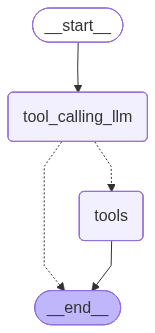

In [34]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [37]:
response

{'messages': [HumanMessage(content='What is the recent ai news', additional_kwargs={}, response_metadata={}, id='ff70cbb1-19b4-4ca7-a6f9-3007a13881fb'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'cdjxd58fg', 'function': {'arguments': '{"query":"recent AI news","search_depth":"advanced","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 1751, 'total_tokens': 1789, 'completion_time': 0.100256733, 'completion_tokens_details': None, 'prompt_time': 0.09053861, 'prompt_tokens_details': None, 'queue_time': 0.051175427, 'total_time': 0.190795343}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e7229-30b8-7ca0-92bc-d5559631a620-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'search

In [36]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://securityboulevard.com/2026/05/the-ai-governance-gap-verizons-2026-dbir-shows-attackers-scaling-ai-while-employees-leak-data-through-it/", "title": "The AI Governance Gap: Verizon\'s 2026 DBIR Shows Attackers Scaling AI While Employees Leak Data Through It - securityboulevard.com", "score": 0.9492946, "published_date": "Thu, 28 May 2026 18:39:14 GMT", "content": "|  |  |  |\\n --- \\n| When | Milestone | Source |\\n| Q3 2024 | DARPA AIxCC semifinal: AI agents find vulns at 37% success rate | DARPA |\\n| Q1 2025 | AIxCC final: 18 real vulns, 6 zero days, $152/finding, 77% rate | DARPA |\\n| Q1 2025 | Claude Opus 4.6 finds 500+ high severity zero days in production OSS | Anthropic Frontier Red Team |\\n| Q1 2025 | GPT-5.3-Codex classified as “High Cyber Capability” | OpenAI Preparedness Framework |\\n| Q1 2025 | Single actor compromises 600+ FortiGate devices across 55 coun

In [38]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (cdjxd58fg)
 Call ID: cdjxd58fg
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://securityboulevard.com/2026/05/the-ai-governance-gap-verizons-2026-dbir-shows-attackers-scaling-ai-while-employees-leak-data-through-it/", "title": "The AI Governance Gap: Verizon's 2026 DBIR Shows Attackers Scaling AI While Employees Leak Data Through It - securityboulevard.com", "score": 0.9492946, "published_date": "Thu, 28 May 2026 18:39:14 GMT", "content": "|  |  |  |\n --- \n| When | Milestone | Source |\n| Q3 2024 | DARPA AIx

In [40]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (sqxk5djwj)
 Call ID: sqxk5djwj
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [43]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()
    
# Current state graph sometimes couldnt perform both tool calls at once for that we use ReAct Agent for better communication

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (vch9657j6)
 Call ID: vch9657j6
  Args:
    query: recent ai news
    search_depth: basic
    topic: news
  multiply (jvawth8bb)
 Call ID: jvawth8bb
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/203943-asana-acquires-startup-stack-ai-for-75-million.html", "title": "Асана компанияси Стакк AI стартапини 75 миллион долларга сотиб олди - Zamin.uz", "score": 0.6420965, "published_date": "Thu, 28 May 2026 20:24:45 GMT", "content": "# Asana acquires startup Stack AI for $75 million. Asana, a leading workflow management platform, has an

### ReAct Agent Architecture

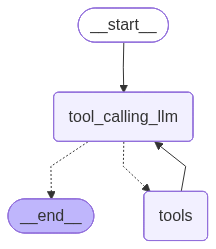

In [44]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
# builder.add_edge("tools", END)
builder.add_edge("tools","tool_calling_llm")        # MAIN CHANGE 

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [45]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (yw10wn6dx)
 Call ID: yw10wn6dx
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
  multiply (gbztehg00)
 Call ID: gbztehg00
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/video/study-evaluates-how-accurate-ai-news-current-events-theres-lot-work-done/", "title": "Study evaluates how accurate AI is on news and current events: \"There's a lot of work to be done\" - CBS News", "score": 0.70580584, "published_date": "Tue, 26 May 2026 21:34:15 GMT", "content": "Image 101: Kouri Richins: Behind the Facade ### Kouri 

## Adding Memory In Agentic Graph

In [46]:
response=graph.invoke({"messages":"Hello my name is Rohan"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Rohan
================================== Ai Message ==================================

Hello Rohan, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [47]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


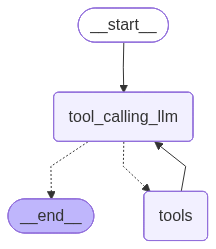

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

# Initialize MemorySaver()
memory = MemorySaver()  

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)      # MAIN CHANGE TO ADD MEMORY

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [49]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Rohan"},config=config)
response

{'messages': [HumanMessage(content='Hi my name is Rohan', additional_kwargs={}, response_metadata={}, id='f1dd1109-0831-4120-b841-9370695e199c'),
  AIMessage(content="Hello Rohan! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1751, 'total_tokens': 1778, 'completion_time': 0.068890056, 'completion_tokens_details': None, 'prompt_time': 0.215423362, 'prompt_tokens_details': None, 'queue_time': 0.05644737, 'total_time': 0.284313418}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e7261-86ce-73c0-a7fd-e1bc1bd3c76b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1751, 'output_tokens': 27, 'total_tokens': 1778})]}

In [50]:
response['messages'][-1].content

"Hello Rohan! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [51]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)
print(response['messages'][-1].content)

Your name is Rohan.


In [53]:
response=graph.invoke({"messages":"Hey do you remember my name"},config=config)

print(response['messages'][-1].content)

Yes, I remember that your name is Rohan.


### Streaming

In [61]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [62]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

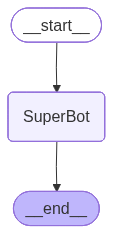

In [63]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder=graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [64]:
## Invocation
config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Rohan And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Rohan And I like cricket', additional_kwargs={}, response_metadata={}, id='f8665839-9e6f-4947-86ef-61e14b924955'),
  AIMessage(content="Nice to meet you, Rohan. Cricket is a fantastic sport, and it's great that you're a fan. Who's your favorite team or player? Are you more into international cricket, like the Indian national team, or do you follow a specific domestic league like the IPL?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 46, 'total_tokens': 104, 'completion_time': 0.173548718, 'completion_tokens_details': None, 'prompt_time': 0.004162417, 'prompt_tokens_details': None, 'queue_time': 0.161364296, 'total_time': 0.177711135}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e7265-abbf-7542-8005-6b5d740dbd1c-0', tool_calls=[], inval

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [65]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Rohan And I like Vollyball"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Rohan, nice to meet you. Volleyball is an exciting sport, isn't it? Do you play volleyball regularly or just enjoy watching it? What's your favorite aspect of the game - the spikes, the blocks, or the strategy involved?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 48, 'total_tokens': 100, 'completion_time': 0.132217617, 'completion_tokens_details': None, 'prompt_time': 0.002963334, 'prompt_tokens_details': None, 'queue_time': 0.158022617, 'total_time': 0.135180951}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e726c-1104-72a0-bb36-76ec94399cf0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 52, 'total_tokens': 100})]}}


In [66]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Rohan And I like Vollyball', additional_kwargs={}, response_metadata={}, id='b92d6d6b-d89e-4b72-8063-ac7c56eab2ed'), AIMessage(content="Hi Rohan, nice to meet you. Volleyball is an exciting sport, isn't it? Do you play volleyball regularly or just enjoy watching it? What's your favorite aspect of the game - the spikes, the blocks, or the strategy involved?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 48, 'total_tokens': 100, 'completion_time': 0.132217617, 'completion_tokens_details': None, 'prompt_time': 0.002963334, 'prompt_tokens_details': None, 'queue_time': 0.158022617, 'total_time': 0.135180951}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e726c-1104-72a0-bb36-76ec94399cf0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata

In [68]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Rohan And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Rohan. Cricket seems to be a popular interest, I just met someone named Krish who also likes cricket. Which format of cricket do you enjoy the most - Test, ODI, or T20? And do you have a favorite cricketer or team that you support?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 101, 'total_tokens': 163, 'completion_time': 0.231959717, 'completion_tokens_details': None, 'prompt_time': 0.006653087, 'prompt_tokens_details': None, 'queue_time': 0.337160323, 'total_time': 0.238612804}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e726e-fa89-7172-af2f-59434e13d22d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 101, 'output_tokens': 62, 'total_tokens': 163})]}}


In [69]:
for chunk in graph_builder.stream({'messages':"I also like vollyball"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='252b574d-01b4-450a-90f3-2ffd62cc8aaa'), AIMessage(content="Nice to meet you, Krish. Cricket is an exciting sport, isn't it? Which team or player is your favorite? Do you play cricket yourself or enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 45, 'total_tokens': 81, 'completion_time': 0.083580792, 'completion_tokens_details': None, 'prompt_time': 0.001422158, 'prompt_tokens_details': None, 'queue_time': 0.161775411, 'total_time': 0.08500295}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e726e-ae97-7f90-a51a-9d18c56e5127-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 36, 'total_tokens': 81}), HumanMe

In [70]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Rohan and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Rohan and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e727b-70be-7d32-b816-86415e437ed6', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Rohan and I like to play cricket', additional_kwargs={}, response_metadata={}, id='e92359a2-1ca3-418e-86a0-0a0657f4be6f')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019e727b-70d1-7683-9e45-1bccb3b1a0d2', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:e850b52f-2a05-dfe3-5ff3-a8cf0865f52a'}, 'parent_ids': ['019e727b-70be-7d32-b816-86415e437ed6']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':